Pronađen GPU na: /device:GPU:0

Treniranje modela: CNN...


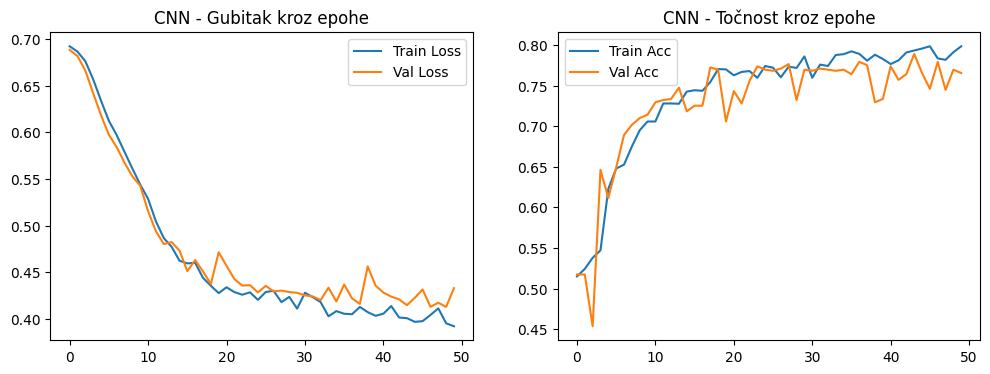


Treniranje modela: LSTM...


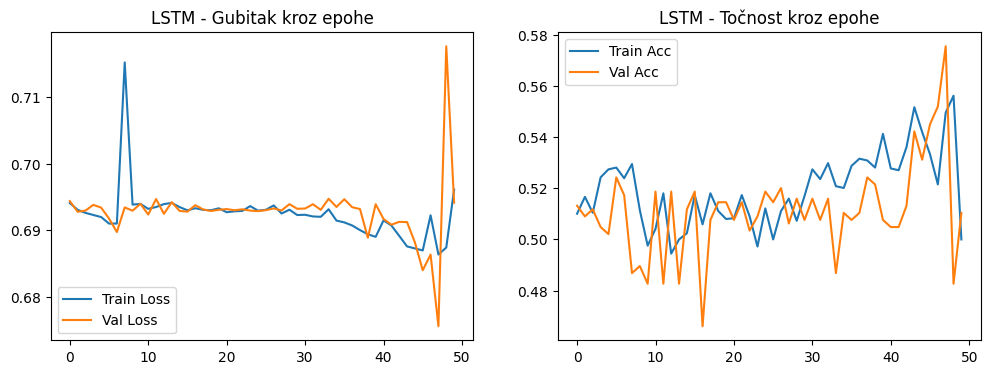

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


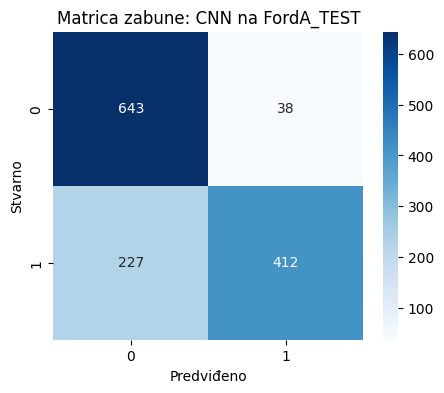

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


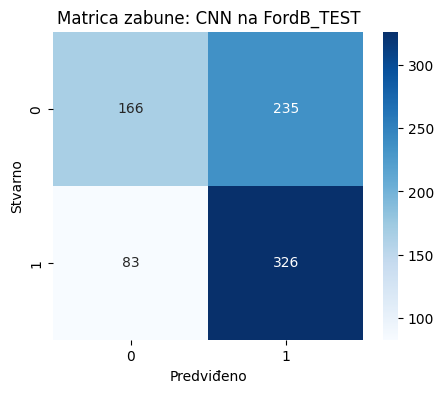

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


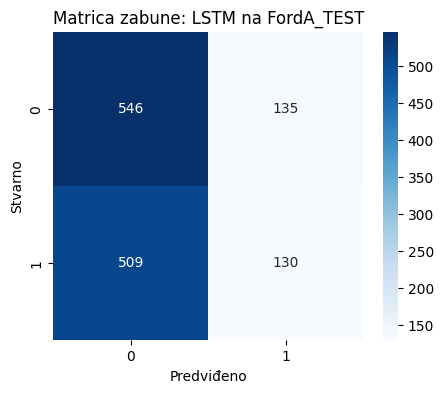

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


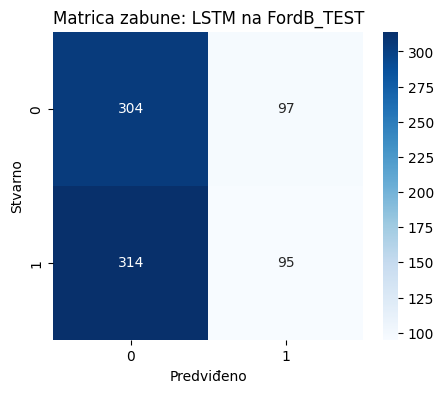


--- ZAVRŠNA USPOREDBA MODELA ---
Model       Skup  Accuracy  Precision   Recall       F1
  CNN FordA_TEST  0.799242   0.915556 0.644757 0.756657
  CNN FordB_TEST  0.607407   0.581105 0.797066 0.672165
 LSTM FordA_TEST  0.512121   0.490566 0.203443 0.287611
 LSTM FordB_TEST  0.492593   0.494792 0.232274 0.316140


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

device_name = tf.test.gpu_device_name()

if device_name != '/device:GPU:0':
    print('GPU nije pronađen. Provjeri postavke Runtimea.')
else:
    print('Pronađen GPU na: {}'.format(device_name))

# --- 1. UČITAVANJE I PREDOBRADA PODATAKA ---
def load_data(filename):
    data = np.loadtxt(filename)
    y = data[:, 0]
    x = data[:, 1:]
    y[y == -1] = 0 # Prebacivanje labela u 0 i 1
    return x, y

# Učitavanje prema specifikaciji zadatka [cite: 8, 11]
x_train_full, y_train_full = load_data("/content/FordA_TRAIN.txt")
x_test_a, y_test_a = load_data("/content/FordA_TEST.txt")
x_test_b, y_test_b = load_data("/content/FordB_TEST.txt")

# Standardizacija podataka (bitno za stabilnost učenja)
mean = x_train_full.mean()
std = x_train_full.std()
x_train_full = (x_train_full - mean) / std
x_test_a = (x_test_a - mean) / std
x_test_b = (x_test_b - mean) / std

# Reshape za 1D CNN i LSTM (samples, steps, features)
x_train_full = x_train_full.reshape((x_train_full.shape[0], x_train_full.shape[1], 1))
x_test_a = x_test_a.reshape((x_test_a.shape[0], x_test_a.shape[1], 1))
x_test_b = x_test_b.reshape((x_test_b.shape[0], x_test_b.shape[1], 1))

# Izdvajanje validacijskog skupa iz FordA_TRAIN [cite: 12]
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)

# --- 2. DEFINIRANJE ARHITEKTURA [cite: 10] ---
def build_cnn(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

def build_lstm(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

input_shape = (x_train.shape[1], 1)
models = {"CNN": build_cnn(input_shape), "LSTM": build_lstm(input_shape)}

# --- 3. TRENIRANJE I VIZUALIZACIJA ---
histories = {}
for name, model in models.items():
    print(f"\nTreniranje modela: {name}...")
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    # Early stopping za sprječavanje preučenja [cite: 12]
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=50, batch_size=128, verbose=0
    )
    histories[name] = history

    # Grafikon gubitka (Loss) i točnosti (Accuracy)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} - Gubitak kroz epohe')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{name} - Točnost kroz epohe')
    plt.legend()
    plt.show()

# --- 4. ZAVRŠNA EVALUACIJA (FordA_TEST i FordB_TEST)  ---
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Stvarno')
    plt.xlabel('Predviđeno')
    plt.show()

final_results = []
for name, model in models.items():
    for set_name, x, y in [("FordA_TEST", x_test_a, y_test_a), ("FordB_TEST", x_test_b, y_test_b)]:
        y_prob = model.predict(x)
        y_pred = (y_prob > 0.5).astype(int)

        # Prikupljanje metrika
        final_results.append({
            "Model": name,
            "Skup": set_name,
            "Accuracy": accuracy_score(y, y_pred),
            "Precision": precision_score(y, y_pred),
            "Recall": recall_score(y, y_pred),
            "F1": f1_score(y, y_pred)
        })

        plot_cm(y, y_pred, f"Matrica zabune: {name} na {set_name}")

# Prikaz rezultata u tablici
df_res = pd.DataFrame(final_results)
print("\n--- ZAVRŠNA USPOREDBA MODELA ---")
print(df_res.to_string(index=False))

In [4]:
import os
print("Datoteke u Colabu:")
print(os.listdir("/content/"))

Datoteke u Colabu:
['.config', 'FordA_TEST.txt', 'FordB_TEST.txt', 'FordA_TRAIN.txt', 'sample_data']
